# California Housing
캘리포니아 지역의 주택 정보(소득, 위치, 방 수 등)를 보고 집값을 예측하는 AI 모델을 만듭니다.
"1990년 기준으로 소득이 X이고, 위치가 Y이면 집값은 얼마일까?"만 예측할 수 있습니다.

데이터 시점: 	1990년 미국 인구조사
지역 범위:  	Berkeley만이 아닌 캘리포니아 주 전체
데이터 수:  	20,640개 (캘리포니아 전체 블록 그룹)

같은 데이터에 6가지 신경망 모델을 적용했을 때 어떤 모델이 가장 정확한지 비교하는 것이 핵심 목표입니다.

In [ ]:
# 데이터 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target          # 단위: $100,000

print(df.shape)                    # (20640, 9)
print(df.describe())

(20640, 9)
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308  

In [2]:
df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


# California Housing

In [31]:
# ============================================
# California Housing - 데이터 준비 (공통)
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 로드
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target  # 단위: $100,000

# X, y 분리
X = df.drop('Price', axis=1).values
y = df['Price'].values

# 학습/테스트 분리 (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 스케일링 (표준화)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}")
print(f"X_test : {X_test_scaled.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")


X_train: (16512, 8)
X_test : (4128, 8)
y_train: (16512,)
y_test : (4128,)


# Step 1. 기본 DNN 회귀 모델

In [32]:
# ============================================
# Step 1. 기본 DNN 회귀 모델
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_dnn = Sequential([
    Dense(128, activation='relu', input_shape=(8,)),
    Dense(64, activation='relu'),
    Dense(1)  # 회귀: 활성화 함수 없음
])

model_dnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_dnn.summary()


/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,473 (37.00 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 0 (0.00 B)

# Step 1. 기본 DNN - 학습

In [33]:
# ============================================
# Step 1. 기본 DNN - 학습
# ============================================
history_dnn = model_dnn.fit(X_train_scaled, y_train,
                            epochs=50,
                            batch_size=128,
                            validation_split=0.2,
                            verbose=1)


Epoch 1/50


I0000 00:00:1775090664.708978    1817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_184697__.9


 94/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9691 - mae: 1.0160

I0000 00:00:1775090665.482588    1817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_184697__.9


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.1855 - mae: 0.7553 - val_loss: 0.6437 - val_mae: 0.5690
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5147 - mae: 0.5123 - val_loss: 0.4754 - val_mae: 0.4961
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4178 - mae: 0.4604 - val_loss: 0.4325 - val_mae: 0.4709
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3822 - mae: 0.4388 - val_loss: 0.4094 - val_mae: 0.4535
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3661 - mae: 0.4293 - val_loss: 0.3937 - val_mae: 0.4432
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3549 - mae: 0.4216 - val_loss: 0.3853 - val_mae: 0.4376
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3453 - mae: 0.4168 - val_loss: 0.3797 - val_mae: 0.4354
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3384 - mae: 0.4115 - val_loss: 0.3676 - val_mae: 0.4273
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3323

# Step 1. 기본 DNN - 테스트 평가

In [34]:
# ============================================
# Step 1. 기본 DNN - 테스트 평가
# ============================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_dnn = model_dnn.predict(X_test_scaled).flatten()

mse_dnn = mean_squared_error(y_test, y_pred_dnn)
mae_dnn = mean_absolute_error(y_test, y_pred_dnn)
r2_dnn = r2_score(y_test, y_pred_dnn)

print(f"[Step 1] 기본 DNN 결과")
print(f"  MSE    : {mse_dnn:.4f}")
print(f"  MAE    : {mae_dnn:.4f}")
print(f"  R² Score: {r2_dnn:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 938us/step
[Step 1] 기본 DNN 결과
  MSE    : 0.2829
  MAE    : 0.3599
  R² Score: 0.7841


# Step 1. 기본 DNN - 학습 과정 시각화

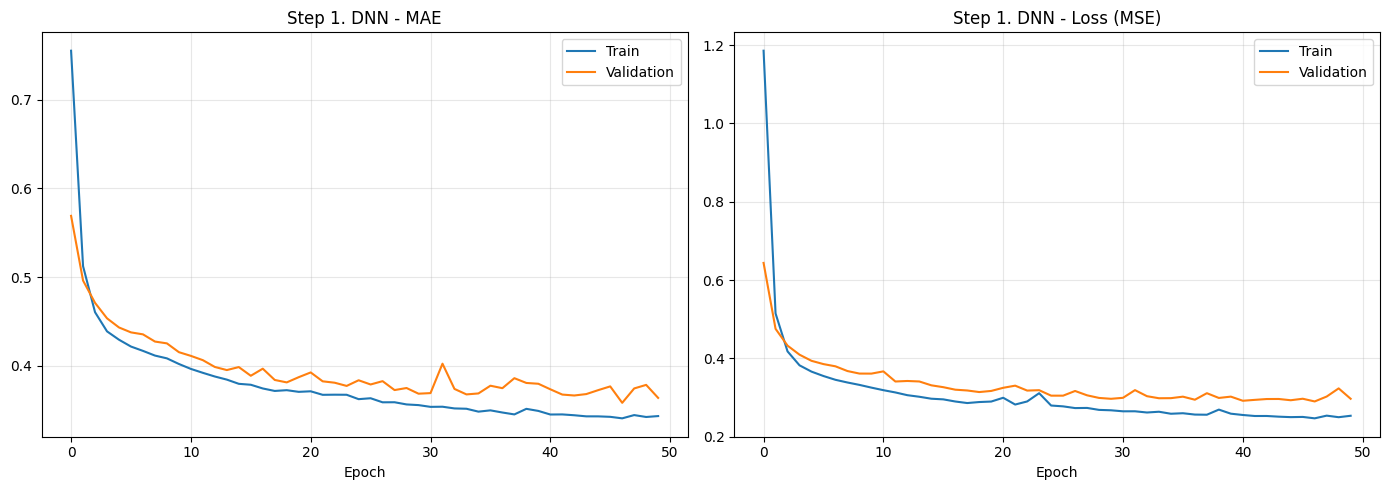

In [35]:
# ============================================
# Step 1. 기본 DNN - 학습 과정 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_dnn.history['mae'], label='Train')
axes[0].plot(history_dnn.history['val_mae'], label='Validation')
axes[0].set_title('Step 1. DNN - MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_dnn.history['loss'], label='Train')
axes[1].plot(history_dnn.history['val_loss'], label='Validation')
axes[1].set_title('Step 1. DNN - Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 2 Deep DNN 모델 구성

In [36]:
# ============================================
# Step 2. Deep DNN 모델 구성
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model_deep = Sequential([
    Dense(256, activation='relu', input_shape=(8,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_deep.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_deep.summary()


/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,105 (184.00 KB)

 Trainable params: 46,337 (181.00 KB)

 Non-trainable params: 768 (3.00 KB)

# Step 2 Deep DNN - 학습

In [37]:
# ============================================
# Step 2. Deep DNN - 학습
# ============================================
history_deep = model_deep.fit(X_train_scaled, y_train,
                              epochs=50,
                              batch_size=128,
                              validation_split=0.2,
                              verbose=1)


Epoch 1/50


I0000 00:00:1775090685.946760    1811 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_216129__.26


101/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0470 - mae: 1.0677

I0000 00:00:1775090687.899250    1816 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_216129__.26


104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 1.2153 - mae: 0.8102 - val_loss: 2.0602 - val_mae: 1.0350
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6710 - mae: 0.6054 - val_loss: 1.0506 - val_mae: 0.7084
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5772 - mae: 0.5610 - val_loss: 0.9248 - val_mae: 0.6559
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5308 - mae: 0.5321 - val_loss: 0.7341 - val_mae: 0.5717
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5154 - mae: 0.5218 - val_loss: 0.6060 - val_mae: 0.5222
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4759 - mae: 0.5032 - val_loss: 0.5913 - val_mae: 0.5215
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4444 - mae: 0.4824 - val_loss: 0.5545 - val_mae: 0.5010
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4274 - mae: 0.4741 - val_loss: 0.5544 - val_mae: 0.5052
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4233

# Step 2 Deep DNN - 테스트 평가

In [38]:
# ============================================
# Step 2. Deep DNN - 테스트 평가
# ============================================
y_pred_deep = model_deep.predict(X_test_scaled).flatten()

mse_deep = mean_squared_error(y_test, y_pred_deep)
mae_deep = mean_absolute_error(y_test, y_pred_deep)
r2_deep = r2_score(y_test, y_pred_deep)

print(f"[Step 2] Deep DNN 결과")
print(f"  MSE    : {mse_deep:.4f}")
print(f"  MAE    : {mae_deep:.4f}")
print(f"  R² Score: {r2_deep:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[Step 2] Deep DNN 결과
  MSE    : 0.3648
  MAE    : 0.4001
  R² Score: 0.7216


# Step 2 Deep DNN - 학습 과정 시각화

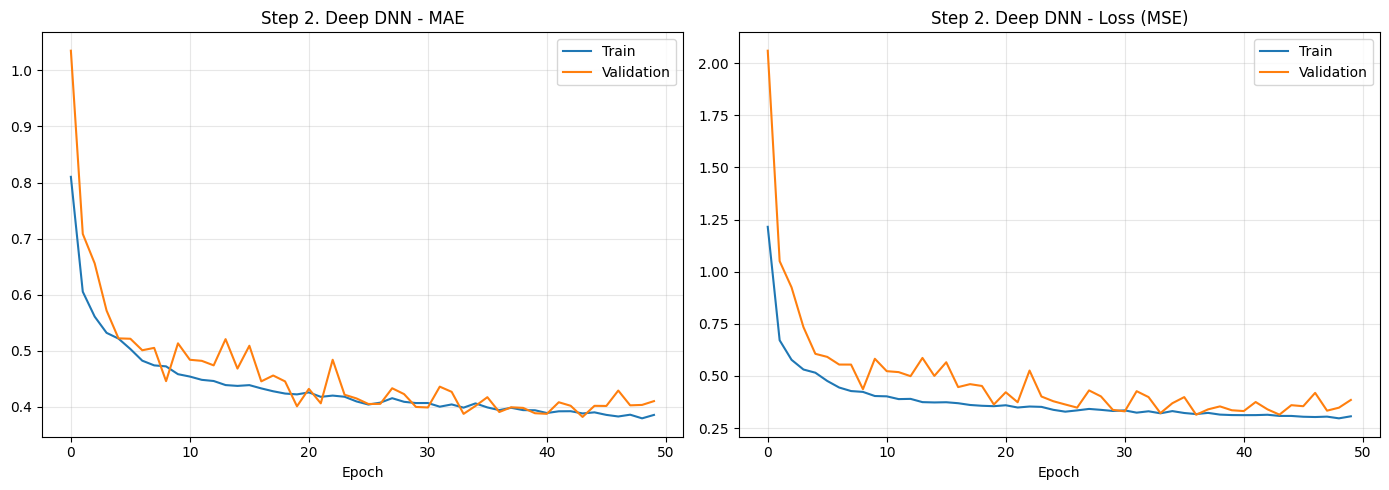

In [39]:
# ============================================
# Step 2. Deep DNN - 학습 과정 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deep.history['mae'], label='Train')
axes[0].plot(history_deep.history['val_mae'], label='Validation')
axes[0].set_title('Step 2. Deep DNN - MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_deep.history['loss'], label='Train')
axes[1].plot(history_deep.history['val_loss'], label='Validation')
axes[1].set_title('Step 2. Deep DNN - Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 3 데이터 reshape (8개 특성 → 8 타임스텝 × 1)

In [40]:
# ============================================
# Step 3. 데이터 reshape (8개 특성 → 8 타임스텝 × 1)
# ============================================
X_train_rnn = X_train_scaled.reshape(-1, 8, 1)
X_test_rnn = X_test_scaled.reshape(-1, 8, 1)

print(f"RNN 입력 shape: {X_train_rnn.shape}")
# (16512, 8, 1) → 8 타임스텝, 1 특성


RNN 입력 shape: (16512, 8, 1)


# Step 3 SimpleRNN 모델 구성

In [41]:
# ============================================
# Step 3. SimpleRNN 모델 구성
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

model_rnn = Sequential([
    Input(shape=(8, 1)),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_rnn.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

# Step 3 SimpleRNN - 학습

In [42]:
# ============================================
# Step 3. SimpleRNN - 학습
# ============================================
history_rnn = model_rnn.fit(X_train_rnn, y_train,
                            epochs=50,
                            batch_size=128,
                            validation_split=0.2,
                            verbose=1)


Epoch 1/50


I0000 00:00:1775090707.676624    1814 dot_merger.cc:481] Merging Dots in computation: sequential_7_1_simple_rnn_1_1_while_body_246096_grad_246299_const_0__.18.clone.clone.clone.clone.clone
I0000 00:00:1775090707.676684    1814 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_246768__.19


 93/104 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7113 - mae: 0.9541

I0000 00:00:1775090708.815427    1814 dot_merger.cc:481] Merging Dots in computation: sequential_7_1_simple_rnn_1_1_while_body_246096_grad_246299_const_0__.18.clone.clone.clone.clone.clone
I0000 00:00:1775090708.815485    1814 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_246768__.19


104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.9246 - mae: 0.6941 - val_loss: 0.5162 - val_mae: 0.5247
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4599 - mae: 0.4940 - val_loss: 0.4536 - val_mae: 0.4729
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4255 - mae: 0.4718 - val_loss: 0.4302 - val_mae: 0.4680
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4102 - mae: 0.4601 - val_loss: 0.4511 - val_mae: 0.4988
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4033 - mae: 0.4561 - val_loss: 0.4357 - val_mae: 0.4902
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3891 - mae: 0.4459 - val_loss: 0.4108 - val_mae: 0.4474
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3960 - mae: 0.4512 - val_loss: 0.4196 - val_mae: 0.4837
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3820 - mae: 0.4409 - val_loss: 0.4130 - val_mae: 0.4763
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3834

# Step 3 SimpleRNN - 테스트 평가

In [43]:
# ============================================
# Step 3. SimpleRNN - 테스트 평가
# ============================================
y_pred_rnn = model_rnn.predict(X_test_rnn).flatten()

mse_rnn = mean_squared_error(y_test, y_pred_rnn)
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
r2_rnn = r2_score(y_test, y_pred_rnn)

print(f"[Step 3] SimpleRNN 결과")
print(f"  MSE    : {mse_rnn:.4f}")
print(f"  MAE    : {mae_rnn:.4f}")
print(f"  R² Score: {r2_rnn:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[Step 3] SimpleRNN 결과
  MSE    : 0.3204
  MAE    : 0.4020
  R² Score: 0.7555


# Step 3 SimpleRNN - 학습 과정 시각화

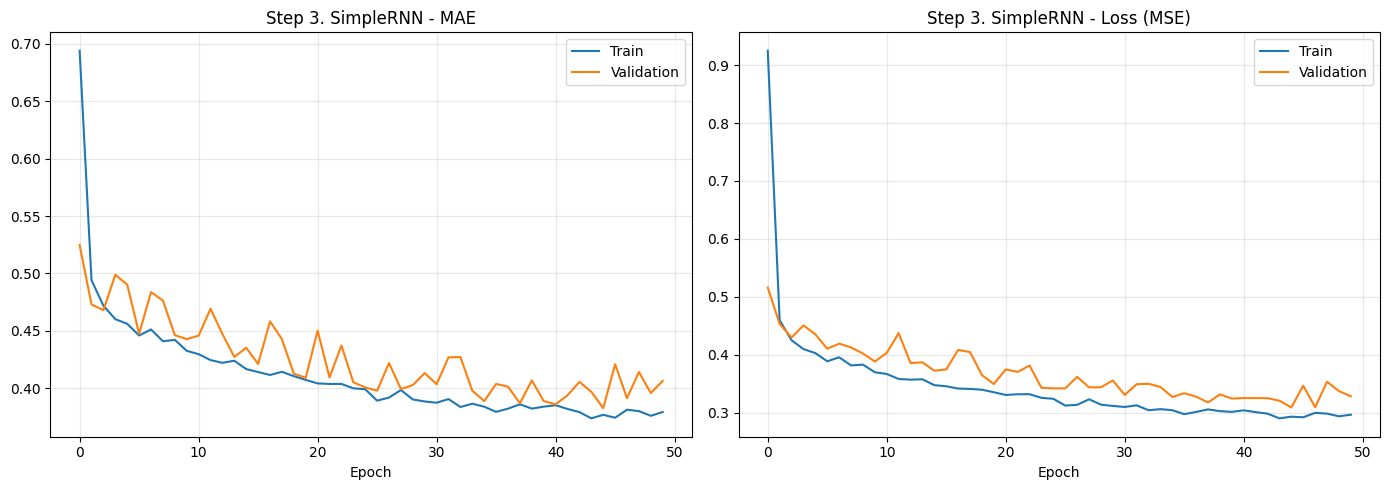

In [44]:
# ============================================
# Step 3. SimpleRNN - 학습 과정 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['mae'], label='Train')
axes[0].plot(history_rnn.history['val_mae'], label='Validation')
axes[0].set_title('Step 3. SimpleRNN - MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_rnn.history['loss'], label='Train')
axes[1].plot(history_rnn.history['val_loss'], label='Validation')
axes[1].set_title('Step 3. SimpleRNN - Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 4 LSTM 모델 구성

In [45]:
# ============================================
# Step 4. LSTM 모델 구성
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model_lstm = Sequential([
    Input(shape=(8, 1)),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

# Step 4 LSTM - 학습

In [46]:
# ============================================
# Step 4. LSTM - 학습
# ============================================
history_lstm = model_lstm.fit(X_train_rnn, y_train,
                              epochs=50,
                              batch_size=128,
                              validation_split=0.2,
                              verbose=1)


Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.0041 - mae: 1.0420 - val_loss: 0.6935 - val_mae: 0.6280
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6535 - mae: 0.6135 - val_loss: 0.6653 - val_mae: 0.6214
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6443 - mae: 0.6086 - val_loss: 0.6587 - val_mae: 0.6006
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6385 - mae: 0.6053 - val_loss: 0.6478 - val_mae: 0.6134
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6281 - mae: 0.6000 - val_loss: 0.6322 - val_mae: 0.5909
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6221 - mae: 0.5943 - val_loss: 0.6317 - val_mae: 0.6097
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.6093 - mae: 0.5875 - val_loss: 0.6216 - val_mae: 0.6040
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5924 - mae: 0.5758 - val_loss: 0.5887 - val_mae: 0.5651
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - l

# Step 4 LSTM - 테스트 평가

In [47]:
# ============================================
# Step 4. LSTM - 테스트 평가
# ============================================
y_pred_lstm = model_lstm.predict(X_test_rnn).flatten()

mse_lstm = mean_squared_error(y_test, y_pred_lstm)
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
r2_lstm = r2_score(y_test, y_pred_lstm)

print(f"[Step 4] LSTM 결과")
print(f"  MSE    : {mse_lstm:.4f}")
print(f"  MAE    : {mae_lstm:.4f}")
print(f"  R² Score: {r2_lstm:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[Step 4] LSTM 결과
  MSE    : 0.3413
  MAE    : 0.3960
  R² Score: 0.7396


# Step 4 LSTM - 학습 과정 시각화

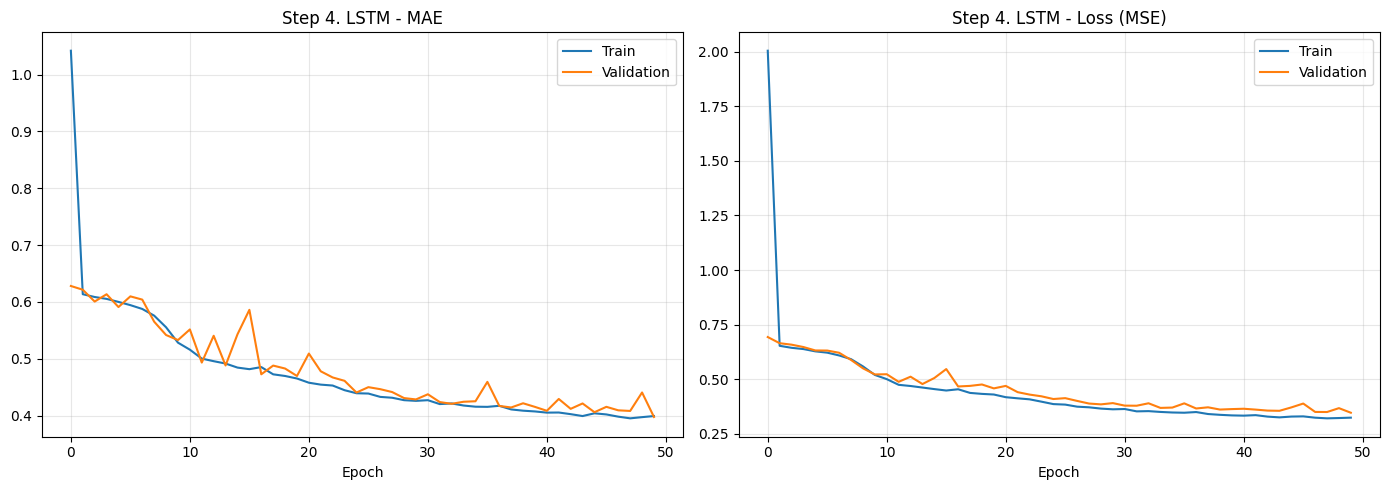

In [48]:
# ============================================
# Step 4. LSTM - 학습 과정 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['mae'], label='Train')
axes[0].plot(history_lstm.history['val_mae'], label='Validation')
axes[0].set_title('Step 4. LSTM - MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_lstm.history['loss'], label='Train')
axes[1].plot(history_lstm.history['val_loss'], label='Validation')
axes[1].set_title('Step 4. LSTM - Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 5 위도/경도 구간화 (Binning)

In [49]:
# ============================================
# Step 5. 위도/경도 구간화 (Binning)
# ============================================
# 위도(Latitude)와 경도(Longitude)를 구간으로 나눠 정수 인덱스로 변환
# → Embedding 입력으로 사용

n_bins = 50  # 50개 구간으로 나눔

# 위도 구간화 (32~42 범위)
lat_bins = np.linspace(32, 42, n_bins)
lat_train_idx = np.digitize(X_train[:, 6], lat_bins)  # 6번째 컬럼: Latitude
lat_test_idx = np.digitize(X_test[:, 6], lat_bins)

# 경도 구간화 (-124~-114 범위)
lon_bins = np.linspace(-124, -114, n_bins)
lon_train_idx = np.digitize(X_train[:, 7], lon_bins)  # 7번째 컬럼: Longitude
lon_test_idx = np.digitize(X_test[:, 7], lon_bins)

# 나머지 6개 수치 특성 (스케일링된 것 사용)
X_train_num = X_train_scaled[:, :6]
X_test_num = X_test_scaled[:, :6]

print(f"위도 인덱스 범위: {lat_train_idx.min()} ~ {lat_train_idx.max()}")
print(f"경도 인덱스 범위: {lon_train_idx.min()} ~ {lon_train_idx.max()}")
print(f"수치 특성 shape: {X_train_num.shape}")


위도 인덱스 범위: 3 ~ 49
경도 인덱스 범위: 0 ~ 48
수치 특성 shape: (16512, 6)


# Step 5 Embedding + DNN 모델 구성

In [50]:
# ============================================
# Step 5. Embedding + DNN 모델 구성
# ============================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout

# 입력 1: 위도 (정수 인덱스)
input_lat = Input(shape=(1,), name='latitude')
emb_lat = Embedding(input_dim=n_bins+2, output_dim=8)(input_lat)
emb_lat = Flatten()(emb_lat)

# 입력 2: 경도 (정수 인덱스)
input_lon = Input(shape=(1,), name='longitude')
emb_lon = Embedding(input_dim=n_bins+2, output_dim=8)(input_lon)
emb_lon = Flatten()(emb_lon)

# 입력 3: 나머지 6개 수치 특성
input_num = Input(shape=(6,), name='numeric')

# 3개 입력 합치기
merged = Concatenate()([emb_lat, emb_lon, input_num])
x = Dense(128, activation='relu')(merged)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
output = Dense(1)(x)

model_emb = Model(inputs=[input_lat, input_lon, input_num], outputs=output)
model_emb.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_emb.summary()


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ latitude            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ longitude           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 8)      │        416 │ latitude[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 8)      │        416 │ longitude[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 8)         │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 8)         │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric             │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 22)        │          0 │ flatten_3[0][0],  │
│ (Concatenate)       │                   │            │ flatten_4[0][0],  │
│                     │                   │            │ numeric[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 128)       │      2,944 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 64)        │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 1)         │         65 │ dense_30[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,097 (47.25 KB)

 Trainable params: 12,097 (47.25 KB)

 Non-trainable params: 0 (0.00 B)

# Step 5 Embedding + DNN - 학습

In [51]:
# ============================================
# Step 5. Embedding + DNN - 학습
# ============================================
history_emb = model_emb.fit(
    [lat_train_idx, lon_train_idx, X_train_num], y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50


I0000 00:00:1775090793.165704    1811 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_307735__.14


 98/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.9557 - mae: 1.2445

I0000 00:00:1775090794.205802    1811 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_307735__.14


104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.6294 - mae: 0.8547 - val_loss: 0.5556 - val_mae: 0.5218
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5524 - mae: 0.5216 - val_loss: 0.4490 - val_mae: 0.4725
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4777 - mae: 0.4856 - val_loss: 0.4060 - val_mae: 0.4469
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4408 - mae: 0.4721 - val_loss: 0.3866 - val_mae: 0.4409
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4155 - mae: 0.4586 - val_loss: 0.3729 - val_mae: 0.4317
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3890 - mae: 0.4419 - val_loss: 0.3807 - val_mae: 0.4222
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3864 - mae: 0.4413 - val_loss: 0.3464 - val_mae: 0.4144
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3774 - mae: 0.4329 - val_loss: 0.3531 - val_mae: 0.4115
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3643

# Step 5 Embedding + DNN - 테스트 평가

In [52]:
# ============================================
# Step 5. Embedding + DNN - 테스트 평가
# ============================================
y_pred_emb = model_emb.predict([lat_test_idx, lon_test_idx, X_test_num]).flatten()

mse_emb = mean_squared_error(y_test, y_pred_emb)
mae_emb = mean_absolute_error(y_test, y_pred_emb)
r2_emb = r2_score(y_test, y_pred_emb)

print(f"[Step 5] Embedding + DNN 결과")
print(f"  MSE    : {mse_emb:.4f}")
print(f"  MAE    : {mae_emb:.4f}")
print(f"  R² Score: {r2_emb:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[Step 5] Embedding + DNN 결과
  MSE    : 0.2495
  MAE    : 0.3335
  R² Score: 0.8096


# Step 5 Embedding + DNN - 학습 과정 시각화

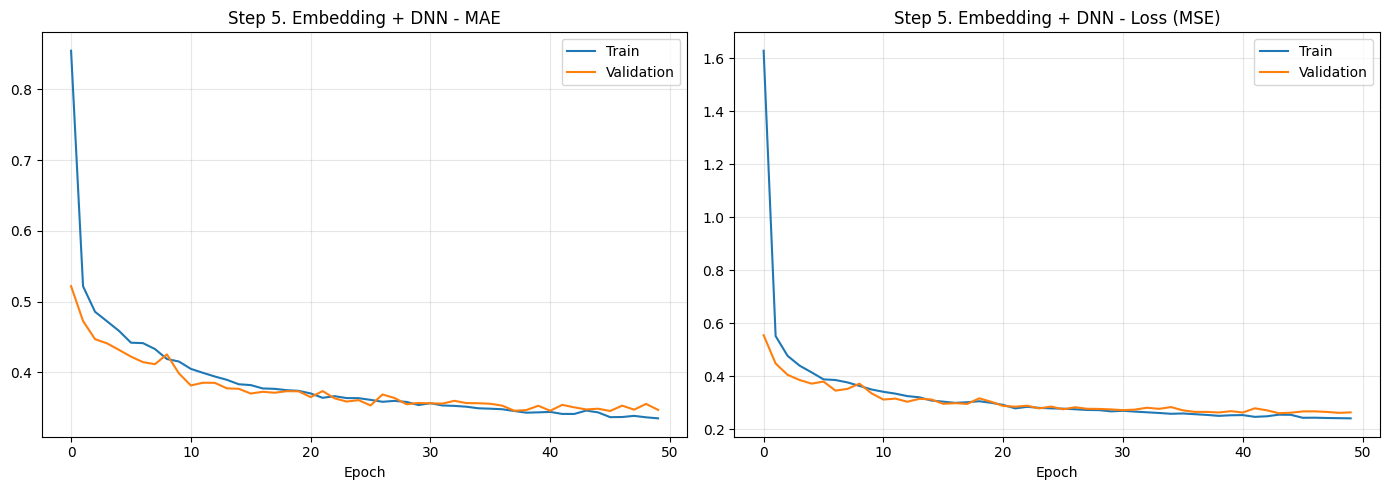

In [53]:
# ============================================
# Step 5. Embedding + DNN - 학습 과정 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_emb.history['mae'], label='Train')
axes[0].plot(history_emb.history['val_mae'], label='Validation')
axes[0].set_title('Step 5. Embedding + DNN - MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_emb.history['loss'], label='Train')
axes[1].plot(history_emb.history['val_loss'], label='Validation')
axes[1].set_title('Step 5. Embedding + DNN - Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 6 CNN 1D 모델 구성

In [54]:
# ============================================
# Step 6. CNN 1D 모델 구성
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input, Dropout

model_cnn = Sequential([
    Input(shape=(8, 1)),
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

model_cnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_cnn.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 8, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 8, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,753 (57.63 KB)

 Trainable params: 14,753 (57.63 KB)

 Non-trainable params: 0 (0.00 B)

# Step 6 CNN 1D - 학습

In [55]:
# ============================================
# Step 6. CNN 1D - 학습
# ============================================
history_cnn = model_cnn.fit(X_train_rnn, y_train,
                            epochs=50,
                            batch_size=128,
                            validation_split=0.2,
                            verbose=1)


Epoch 1/50


I0000 00:00:1775090811.219646    1816 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_338333__.19


 94/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8106 - mae: 1.2853

I0000 00:00:1775090812.366526    1817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_338333__.19


104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.6305 - mae: 0.9199 - val_loss: 0.6255 - val_mae: 0.5947
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6149 - mae: 0.5713 - val_loss: 0.4786 - val_mae: 0.4900
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5449 - mae: 0.5318 - val_loss: 0.4536 - val_mae: 0.4618
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4997 - mae: 0.5099 - val_loss: 0.4266 - val_mae: 0.4641
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4806 - mae: 0.4997 - val_loss: 0.4040 - val_mae: 0.4478
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4634 - mae: 0.4879 - val_loss: 0.4027 - val_mae: 0.4479
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4620 - mae: 0.4832 - val_loss: 0.3876 - val_mae: 0.4290
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4513 - mae: 0.4798 - val_loss: 0.3908 - val_mae: 0.4233
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4311

# Step 6 CNN 1D - 테스트 평가

In [56]:
# ============================================
# Step 6. CNN 1D - 테스트 평가
# ============================================
y_pred_cnn = model_cnn.predict(X_test_rnn).flatten()

mse_cnn = mean_squared_error(y_test, y_pred_cnn)
mae_cnn = mean_absolute_error(y_test, y_pred_cnn)
r2_cnn = r2_score(y_test, y_pred_cnn)

print(f"[Step 6] CNN 1D 결과")
print(f"  MSE    : {mse_cnn:.4f}")
print(f"  MAE    : {mae_cnn:.4f}")
print(f"  R² Score: {r2_cnn:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[Step 6] CNN 1D 결과
  MSE    : 0.2754
  MAE    : 0.3648
  R² Score: 0.7898


# Step 6 CNN 1D - 학습 과정 시각화

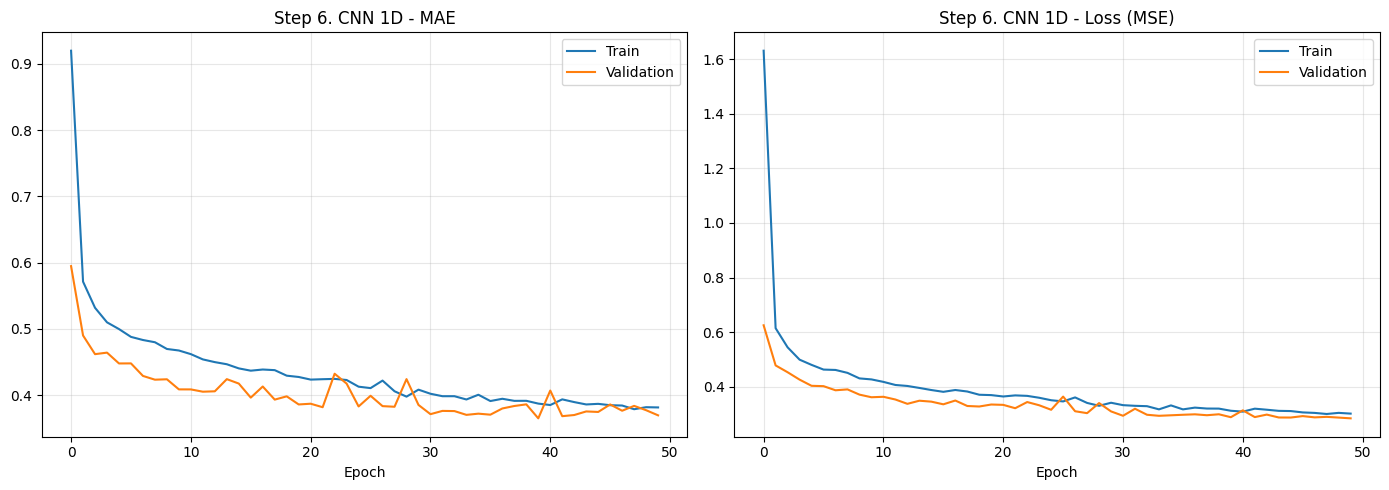

In [57]:
# ============================================
# Step 6. CNN 1D - 학습 과정 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn.history['mae'], label='Train')
axes[0].plot(history_cnn.history['val_mae'], label='Validation')
axes[0].set_title('Step 6. CNN 1D - MAE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn.history['loss'], label='Train')
axes[1].plot(history_cnn.history['val_loss'], label='Validation')
axes[1].set_title('Step 6. CNN 1D - Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 7 전체 실험 결과 비교표

In [58]:
# ============================================
# 전체 실험 결과 비교표
# ============================================
import pandas as pd

results = {
    'Step': ['Step 1', 'Step 2', 'Step 3', 'Step 4', 'Step 5', 'Step 6'],
    '모델': ['기본 DNN', 'Deep DNN', 'SimpleRNN', 'LSTM', 'Embedding + DNN', 'CNN 1D'],
    'MSE': [mse_dnn, mse_deep, mse_rnn, mse_lstm, mse_emb, mse_cnn],
    'MAE': [mae_dnn, mae_deep, mae_rnn, mae_lstm, mae_emb, mae_cnn],
    'R² Score': [r2_dnn, r2_deep, r2_rnn, r2_lstm, r2_emb, r2_cnn]
}

df_results = pd.DataFrame(results)
df_results = df_results.set_index('Step')

# 소수점 4자리로 표시
df_results['MSE'] = df_results['MSE'].round(4)
df_results['MAE'] = df_results['MAE'].round(4)
df_results['R² Score'] = df_results['R² Score'].round(4)

df_results


,모델,MSE,MAE,R² Score
Step,,,,
Step 1,기본 DNN,0.2829,0.3599,0.7841
Step 2,Deep DNN,0.3648,0.4001,0.7216
Step 3,SimpleRNN,0.3204,0.4020,0.7555
Step 4,LSTM,0.3413,0.3960,0.7396
Step 5,Embedding + DNN,0.2495,0.3335,0.8096
Step 6,CNN 1D,0.2754,0.3648,0.7898


# 결과 인사이트
① Embedding + DNN이 1위인 이유
위도/경도를 구간화 → 임베딩으로 변환하여 지역 특성을 벡터로 학습
집값은 **위치(지역)**에 가장 크게 영향받기 때문에 위치 임베딩이 효과적
숫자로 넣으면 "위도 37과 38은 비슷"이지만, 임베딩은 지역별 고유 특성 학습

② RNN/LSTM이 낮은 이유
이 데이터는 시계열(시간 순서)이 아닌 테이블 데이터
8개 특성을 억지로 시퀀스로 변환했지만 특성 간 순서에 의미가 없음
RNN/LSTM은 "소득 → 방수 → 인구 → 위치" 순서에서 패턴을 찾으려 했지만 효과 없음

③ Deep DNN이 기본 DNN보다 낮은 이유
데이터 2만 건에 비해 모델이 너무 복잡 (256→128→64→32)
Dropout, BatchNorm이 오히려 학습을 방해 (과소적합)
단순한 구조가 이 데이터에는 더 적합

④ CNN 1D가 준수한 이유
인접 특성 간 국소 패턴을 감지 (예: 방수+침실수, 위도+경도)
시퀀스 순서와 무관하게 근처 특성끼리 묶어서 학습